In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("data.csv")

In [3]:
df =  pd.DataFrame(data)

In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
# Data Cleaning and Preprocessing

In [6]:

def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float(value)
df['rate'] = df['rate'].apply(handleRate)

In [7]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [8]:
df.info

<bound method DataFrame.info of                       name online_order book_table  rate  votes  \
0                    Jalsa          Yes        Yes   4.1    775   
1           Spice Elephant          Yes         No   4.1    787   
2          San Churro Cafe          Yes         No   3.8    918   
3    Addhuri Udupi Bhojana           No         No   3.7     88   
4            Grand Village           No         No   3.8    166   
..                     ...          ...        ...   ...    ...   
143       Melting Melodies           No         No   3.3      0   
144        New Indraprasta           No         No   3.3      0   
145           Anna Kuteera          Yes         No   4.0    771   
146                 Darbar           No         No   3.0     98   
147          Vijayalakshmi          Yes         No   3.9     47   

     approx_cost(for two people) listed_in(type)  
0                            800          Buffet  
1                            800          Buffet  
2         

In [9]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [10]:
#Exploring Restaurant Type

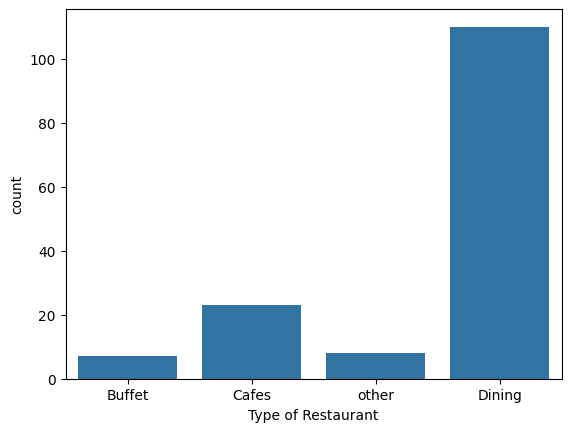

In [31]:
sb.countplot(x=df['listed_in(type)'])
plt.xlabel("Type of Restaurant")
plt.savefig("TypesofRestarunt.png")
plt.show()

In [12]:
grouped_data = df.groupby("listed_in(type)")["votes"].sum()

In [13]:
grouped_data

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

In [14]:
results = pd.DataFrame({"votes":grouped_data})

In [15]:
results

,votes
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


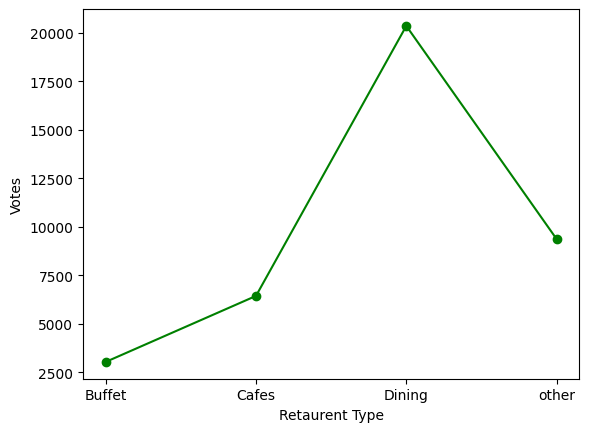

In [33]:
plt.plot(results,c='green',marker="o")
plt.xlabel("Retaurent Type")
plt.ylabel("Votes")
plt.savefig("VotesofRestaurant.png")
plt.show()

In [17]:
#Most Voted Restaurant

In [18]:
max_voted_restaurant = df.loc[df['votes'] == df["votes"].max(),'name']

In [19]:
max_voted_restaurant

38    Empire Restaurant
Name: name, dtype: object

In [20]:
#Online Order Availability

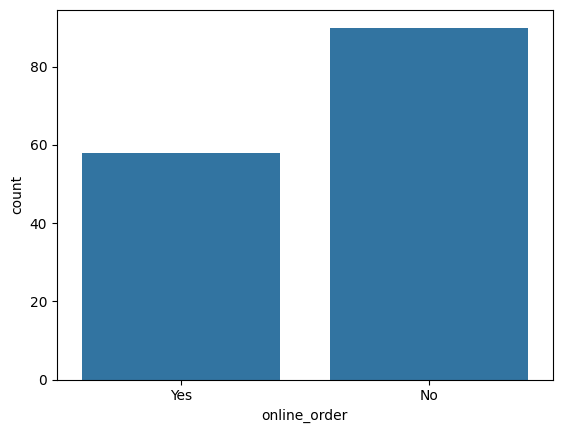

In [34]:
sb.countplot(x = df["online_order"])
plt.savefig("OnlineVSOflineOrders.png")
plt.show()

In [22]:
#Ratings

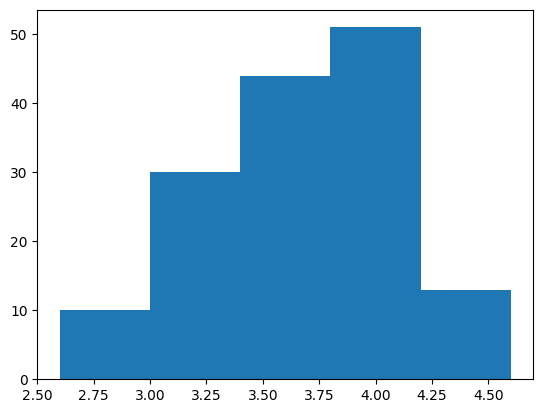

In [35]:
plt.hist(df['rate'],bins=5)
plt.savefig("Ratings.png")
plt.show()

In [24]:
#Approximate cost of Couples

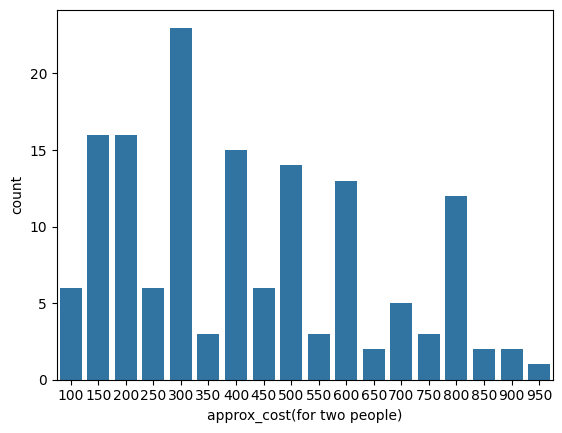

In [36]:
sb.countplot(x=df["approx_cost(for two people)"])
plt.savefig("CodtofCouples.png")
plt.show()

In [26]:
#Ratings Comparison - Online vs Offline Orders

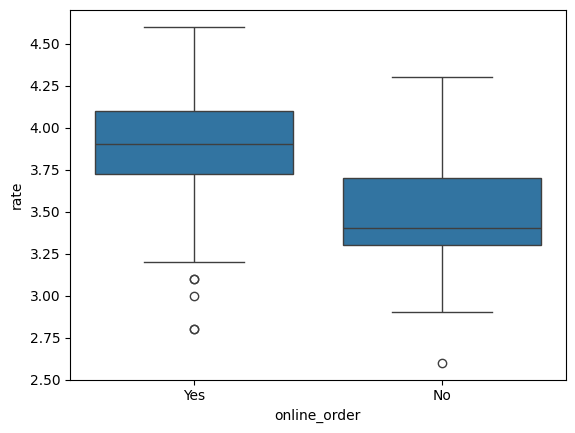

In [37]:
sb.boxplot(x="online_order",y="rate",data=df)
plt.savefig("RantingandOnlineOrders.png")
plt.show()

In [38]:
#Order Mode Preferences by Restaurant Type

online_order     No  Yes
listed_in(type)         
Buffet            3    4
Cafes             8   15
Dining           77   33
other             2    6


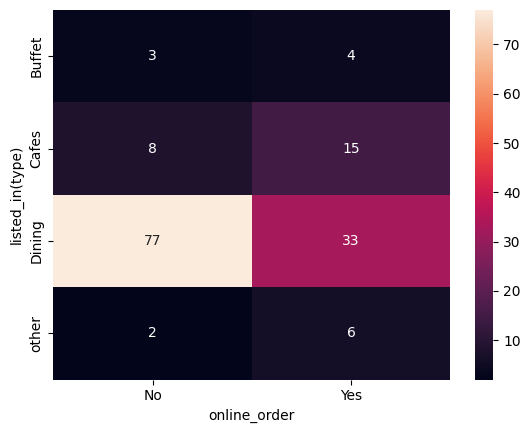

In [39]:
pivot_table = df.pivot_table(index='listed_in(type)',columns="online_order",aggfunc='size',fill_value=0)
print(pivot_table)

sb.heatmap(pivot_table,annot=True)
plt.savefig("OrderMode.png")
plt.show()
